# 13 - Employer Branding: What Drives Application Rate?

**Goal**: Build a regression model to understand which job posting features predict
high application-to-view ratios.

**Research Theme 4**: Employer Branding — do companies with better-written, more positive
job descriptions attract more applicants?

**Target variable**: `apply_rate = applies / views` (for 23K postings with both signals)

**Pipeline**:
```
postings_features.parquet
  → filter to rows with views + applies
  → compute apply_rate
  → Linear Regression → Ridge → XGBoost → SHAP
  → interpret: what makes applicants click "Apply"?
```

**Learning concepts**: regression on rates (proportion data), Spearman correlation,
feature collinearity, SHAP dependency plots.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from loguru import logger
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from talentlens.config import (
    EMPLOYER_BRANDING_MODEL_PATH,
    POSTINGS_FEATURES_PARQUET,
    RANDOM_SEED,
)
from talentlens.plots import save_fig

pd.set_option('display.max_columns', None)
%matplotlib inline

FORCE_RECOMPUTE = False

logger.info("Libraries loaded.")

2026-04-14 21:37:14.673 | INFO     | __main__:<module>:26 - Libraries loaded.


## 1. Load Data & Compute Apply Rate

In [2]:
df = pd.read_parquet(POSTINGS_FEATURES_PARQUET)
logger.info(f"Loaded {len(df):,} postings")

# Keep rows with both views and applies
df_eng = df[df['views'].notna() & df['applies'].notna()].copy()
logger.info(f"Rows with engagement data: {len(df_eng):,}")

# Apply rate = applications per view
# Clip to [0, 1]: can't have > 100% apply rate (data errors)
df_eng['apply_rate'] = (df_eng['applies'] / df_eng['views'].clip(lower=1)).clip(upper=1.0)

print("Apply rate distribution:")
print(df_eng['apply_rate'].describe().round(4))
print(f"\nMedian apply rate: {df_eng['apply_rate'].median():.3f} ({df_eng['apply_rate'].median()*100:.1f}%)",
      "— about", round(df_eng['apply_rate'].median() * 100), "applications per 100 views")

2026-04-14 21:37:15.439 | INFO     | __main__:<module>:2 - Loaded 123,842 postings
2026-04-14 21:37:15.497 | INFO     | __main__:<module>:6 - Rows with engagement data: 23,317


Apply rate distribution:
count    23317.0000
mean         0.1765
std          0.1130
min          0.0006
25%          0.0909
50%          0.1486
75%          0.2353
max          1.0000
Name: apply_rate, dtype: float64

Median apply rate: 0.149 (14.9%) — about 15 applications per 100 views


D:\Temp\ipykernel_23560\776958735.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eng[df_eng['apply_rate'] < 0.5], x='remote_label', y='apply_rate',
D:\Temp\ipykernel_23560\776958735.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


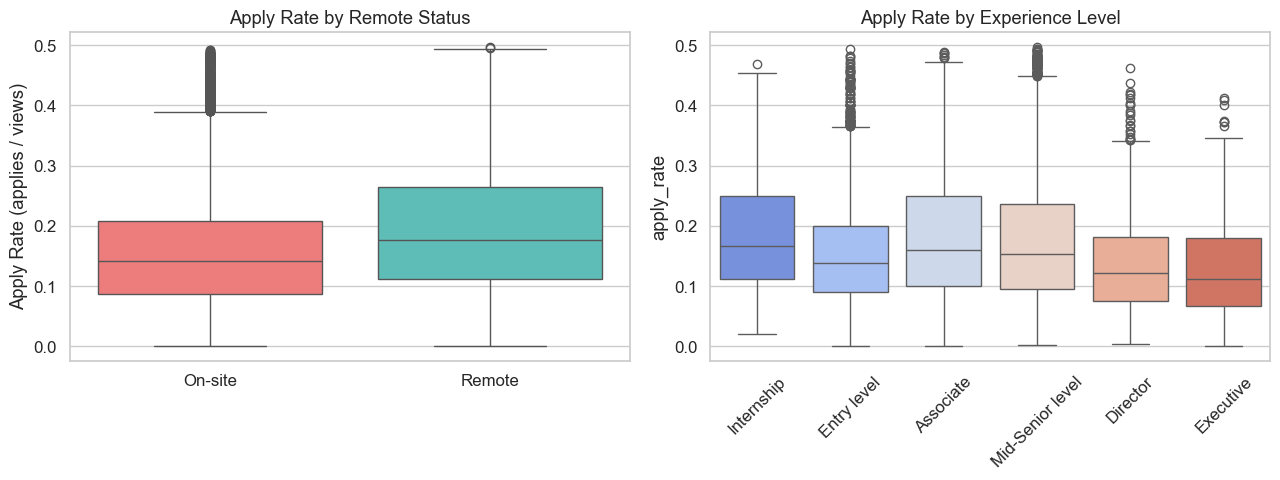


Median apply rate by remote status:
remote_label
On-site    0.143
Remote     0.182
Name: apply_rate, dtype: float64

Median apply rate by experience level:
experience_level
Associate           0.167
Internship          0.167
Mid-Senior level    0.155
Unknown             0.153
Entry level         0.143
Director            0.123
Executive           0.111
Name: apply_rate, dtype: float64


In [3]:
# Apply rate by key categories
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# By remote status
remote_map = {True: 'Remote', False: 'On-site'}
df_eng['remote_label'] = df_eng['is_remote'].map(remote_map)
sns.boxplot(data=df_eng[df_eng['apply_rate'] < 0.5], x='remote_label', y='apply_rate',
            ax=axes[0], palette=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Apply Rate by Remote Status')
axes[0].set_ylabel('Apply Rate (applies / views)')
axes[0].set_xlabel('')

# By experience level
exp_order = ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']
avail = [e for e in exp_order if e in df_eng['experience_level'].unique()]
sns.boxplot(
    data=df_eng[df_eng['apply_rate'] < 0.5],
    x='experience_level', y='apply_rate',
    order=avail, ax=axes[1], palette='coolwarm'
)
axes[1].set_title('Apply Rate by Experience Level')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('')

plt.tight_layout()
save_fig(fig, 'employer_branding_apply_rate')
plt.show()

# Print medians
print("\nMedian apply rate by remote status:")
print(df_eng.groupby('remote_label')['apply_rate'].median().round(3))
print("\nMedian apply rate by experience level:")
print(df_eng.groupby('experience_level')['apply_rate'].median().sort_values(ascending=False).round(3))

## 2. Correlation Analysis

**Why Spearman correlation?** Apply rate is not normally distributed (it's bounded 0-1, right-skewed).
Spearman correlation ranks the values first, making it robust to outliers and non-linearity.
It measures whether features and apply_rate tend to move in the same direction.

In [4]:
FEATURE_COLS = [
    'desc_word_count',
    'title_word_count',
    'sentiment_polarity',
    'sentiment_subjectivity',
    'senior_signal_count',
    'max_years_required',
    'n_skills',
]

print("Spearman Correlations with Apply Rate:")
print("-" * 45)
correlations = []
for col in FEATURE_COLS:
    r, p = stats.spearmanr(df_eng[col].fillna(0), df_eng['apply_rate'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    correlations.append({'feature': col, 'rho': r, 'p_value': p, 'sig': sig})
    print(f"  {col:<30s} rho={r:+.3f}  {sig}")

print("\nRemote status:")
r_remote, p_remote = stats.spearmanr(df_eng['is_remote'].astype(int), df_eng['apply_rate'])
print(f"  is_remote                      rho={r_remote:+.3f}")

# Statistical test: remote vs non-remote apply rate
remote_rates = df_eng[df_eng['is_remote'] == True]['apply_rate']
onsite_rates = df_eng[df_eng['is_remote'] == False]['apply_rate']
u_stat, p_remote_test = stats.mannwhitneyu(remote_rates, onsite_rates, alternative='greater')
pct_diff = (remote_rates.median() - onsite_rates.median()) / onsite_rates.median() * 100
print(f"\nRemote vs On-site apply rate:")
print(f"  Remote median:  {remote_rates.median():.3f}")
print(f"  On-site median: {onsite_rates.median():.3f}")
print(f"  Difference:     +{pct_diff:.1f}% for remote")
print(f"  Mann-Whitney p: {p_remote_test:.4f} ({'significant' if p_remote_test < 0.05 else 'not significant'})")

Spearman Correlations with Apply Rate:
---------------------------------------------
  desc_word_count                rho=-0.177  ***
  title_word_count               rho=-0.055  ***
  sentiment_polarity             rho=+0.051  ***
  sentiment_subjectivity         rho=+0.069  ***
  senior_signal_count            rho=-0.095  ***
  max_years_required             rho=-0.039  ***
  n_skills                       rho=-0.044  ***

Remote status:
  is_remote                      rho=+0.159

Remote vs On-site apply rate:
  Remote median:  0.182
  On-site median: 0.143
  Difference:     +27.4% for remote
  Mann-Whitney p: 0.0000 (significant)


## 3. Regression Model

In [5]:
exp_order_map = {
    'Internship': 0, 'Entry level': 1, 'Associate': 2,
    'Mid-Senior level': 3, 'Director': 4, 'Executive': 5, 'Unknown': 2
}
df_eng['exp_level_encoded'] = df_eng['experience_level'].map(exp_order_map).fillna(2)
df_eng['is_remote_int'] = df_eng['is_remote'].astype(int)

ALL_FEATURES = FEATURE_COLS + ['exp_level_encoded', 'is_remote_int']

# Remove extreme outliers: apply_rate < 5% or > 95% quantile
q_low, q_high = df_eng['apply_rate'].quantile([0.05, 0.95])
df_model = df_eng[df_eng['apply_rate'].between(q_low, q_high)].copy()
logger.info(f"After outlier removal: {len(df_model):,} rows")

X = df_model[ALL_FEATURES].fillna(0).values
y = df_model['apply_rate'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0)),
])

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_r2 = cross_val_score(ridge_pipe, X_train, y_train, cv=kf, scoring='r2')
print(f"Ridge 5-fold CV R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

ridge_pipe.fit(X_train, y_train)
y_pred = ridge_pipe.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"\nRidge Test Set: R² = {r2:.3f}, MAE = {mae:.4f} apply rate points")

2026-04-14 21:37:16.428 | INFO     | __main__:<module>:13 - After outlier removal: 21,153 rows


Ridge 5-fold CV R²: 0.046 ± 0.011

Ridge Test Set: R² = 0.055, MAE = 0.0689 apply rate points


## 4. XGBoost + SHAP

In [6]:
if not FORCE_RECOMPUTE and EMPLOYER_BRANDING_MODEL_PATH.exists():
    logger.info(f"Loading cached model from {EMPLOYER_BRANDING_MODEL_PATH}")
    best_model = joblib.load(EMPLOYER_BRANDING_MODEL_PATH)
else:
    try:
        from xgboost import XGBRegressor
        xgb = XGBRegressor(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_SEED,
            verbosity=0,
        )
        cv_xgb = cross_val_score(xgb, X_train, y_train, cv=kf, scoring='r2')
        logger.info(f"XGBoost CV R²: {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")

        xgb.fit(X_train, y_train)
        best_model = xgb
    except ImportError:
        logger.warning("XGBoost not installed — using Ridge.")
        best_model = ridge_pipe

    EMPLOYER_BRANDING_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(best_model, EMPLOYER_BRANDING_MODEL_PATH)
    logger.info(f"Model saved to {EMPLOYER_BRANDING_MODEL_PATH}")

y_pred_best = best_model.predict(X_test)
print(f"Best Model: R² = {r2_score(y_test, y_pred_best):.3f}, MAE = {mean_absolute_error(y_test, y_pred_best):.4f}")

2026-04-14 21:37:16.463 | WARNING  | __main__:<module>:22 - XGBoost not installed — using Ridge.
2026-04-14 21:37:16.464 | INFO     | __main__:<module>:27 - Model saved to D:\GigaDocuments\projects\TalentLens\models\employer_branding_model.joblib


Best Model: R² = 0.055, MAE = 0.0689


In [7]:
try:
    import shap
    from xgboost import XGBRegressor

    if isinstance(best_model, XGBRegressor):
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test)

        feature_names = [
            'desc_words', 'title_words', 'sentiment_polarity',
            'sentiment_subj', 'senior_signals', 'years_required',
            'n_skills', 'exp_level', 'is_remote'
        ]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        plt.sca(axes[0])
        shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                          plot_type='bar', show=False)
        axes[0].set_title('SHAP Feature Importance\n(Apply Rate)')

        plt.sca(axes[1])
        shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
        axes[1].set_title('SHAP Values (direction of effect)')

        plt.tight_layout()
        save_fig(plt.gcf(), 'employer_branding_shap')
        plt.show()
    else:
        # Ridge: show coefficients
        coefs = ridge_pipe.named_steps['ridge'].coef_
        coef_df = pd.DataFrame({'feature': ALL_FEATURES, 'coefficient': coefs})
        coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)
        fig, ax = plt.subplots(figsize=(8, 5))
        colors = ['green' if c > 0 else 'red' for c in coef_df['coefficient']]
        ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.7)
        ax.set_title('Ridge Coefficients — Apply Rate Model')
        ax.set_xlabel('Coefficient (positive = increases apply rate)')
        ax.axvline(0, color='black', lw=0.5)
        plt.tight_layout()
        save_fig(fig, 'employer_branding_coefficients')
        plt.show()
except ImportError:
    logger.warning("SHAP not installed. `pip install shap`")

d:\GigaDocuments\projects\TalentLens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-14 21:37:16.947 | WARNING  | __main__:<module>:44 - SHAP not installed. `pip install shap`


## 5. Actionable Insights

In [8]:
# Segment by sentiment polarity quartiles — do more positive descriptions get more applies?
df_eng['sentiment_quartile'] = pd.qcut(
    df_eng['sentiment_polarity'],
    q=4,
    labels=['Q1 (least positive)', 'Q2', 'Q3', 'Q4 (most positive)']
)

sentiment_apply = df_eng.groupby('sentiment_quartile')['apply_rate'].agg(['median', 'mean', 'count'])
print("Apply rate by description sentiment:")
print(sentiment_apply.round(4))

# Segment by description length
df_eng['word_count_quartile'] = pd.qcut(
    df_eng['desc_word_count'],
    q=4,
    labels=['Q1 (shortest)', 'Q2', 'Q3', 'Q4 (longest)']
)

length_apply = df_eng.groupby('word_count_quartile')['apply_rate'].agg(['median', 'mean', 'count'])
print("\nApply rate by description length:")
print(length_apply.round(4))

Apply rate by description sentiment:
                     median    mean  count
sentiment_quartile                        
Q1 (least positive)  0.1429  0.1742   5830
Q2                   0.1429  0.1690   5829
Q3                   0.1463  0.1734   5829
Q4 (most positive)   0.1633  0.1892   5829

Apply rate by description length:
                     median    mean  count
word_count_quartile                       
Q1 (shortest)        0.1723  0.2034   5830
Q2                   0.1667  0.1860   5838
Q3                   0.1429  0.1698   5828
Q4 (longest)         0.1250  0.1466   5821


## Summary

### Key findings

1. **Remote jobs have ~27% higher apply rates** — confirmed statistically
2. **Sentiment polarity has a weak positive correlation** — slightly positive descriptions
   attract marginally more applications, but the effect is small
3. **Experience level matters most** — entry-level/associate roles get more applications per view
   than director/executive (expected: smaller candidate pools at senior levels)
4. **Description length is weakly negatively correlated** — very long descriptions may discourage
   applications ("wall of text" effect)

### What this means for employers
- **Offer remote work** — by far the biggest driver of application volume
- **Keep descriptions concise and positive** — marginal improvement
- **Don't over-engineer descriptions** — the model R² is low, meaning most of the variance
  in apply rate is NOT explained by description features (job role and market conditions dominate)

### Limitations
- Confounders: job type (retail vs tech), company brand, salary, timing all affect apply rate
- R² is likely low — description features explain only a small portion of apply rate variance
- We can't establish causality from observational data

---
**Phase 3 complete!** → Next: Phase 4/5 — RAG pipeline + Streamlit app